# NiI₂: simulated ARPES on the (001) cleave vs. chemical potential

**NiI₂** is the layered transition-metal dihalide that shot to prominence as a **type-II (magnetically-induced) multiferroic** — bulk (Kurumaji *et al.*, *Phys. Rev. B* **87**, 014429 (2013)) and, remarkably, down to the monolayer (Song *et al.*, *Nature* **602**, 601 (2022)). Its ground state is an incommensurate proper-screw helimagnet driven by frustration + spin-orbit coupling on the heavy iodine. Here we take the **experimental room-temperature structure** (Crystallography Open Database entry 9009133; Wyckoff, *Crystal Structures*, 2nd ed., 1963), do a **PBE+D3+U** calculation (Liechtenstein $U=3.24$, $J_H=0.68\,$eV on Ni-$3d$ from cRPA, plus a Grimme-D3 van-der-Waals correction — matching Kapeghian *et al.*, *Phys. Rev. B* **109**, 014403 (2024); plain PBE badly underbinds this correlated Mott-Hubbard $d$-shell), build Wannier functions for the near-$E_F$ Ni-$3d$ / I-$5p$ manifold, and use `analysis.surface`'s Green's-function decimation to **simulate an ARPES experiment** on the van-der-Waals cleave (surface ⟂ $c$) as a function of the **chemical-potential position** (electron/hole doping, rigid-band).

**Magnetic order for this PBE pass.** The true helimagnet is incommensurate and non-collinear. The simplest *collinear* proxy is **A-type**: ferromagnetic triangular Ni planes stacked antiferromagnetically along $c$. (Intralayer AFM is impossible collinearly — a triangular nearest-neighbour antiferromagnet is geometrically frustrated.) On the experimental **3R / ABC-stacked** ($R\bar3m$) lattice every *primitive* vector advances one Ni layer and therefore flips the A-type spin, so the collinear magnetic cell is the **index-2 'even-layer' sublattice** of the primitive cell — a 2-formula-unit cell (2 Ni ↑/↓ + 4 I) that keeps the hexagonal in-plane axes and takes two Ni layers along $c$. This is the *smallest* cell that can host A-type AFM; the tilted stacking vector (unavoidable for ABC packing) is handled by the surface decimation exactly as the rhombohedral $(1,1,1)$ cleave was for Bi₂Se₃ (notebook 03).

*New machinery this notebook exercises:* per-sublattice magnetic species in the direct-input QE driver (`qe.magnetization_keys` + ASE tags → distinct `Ni1`/`Ni2` species with opposite `starting_magnetization`).

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV, EV_TO_HARTREE
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not notebooks/-specific
NCORES = 16
waw.set_num_threads(NCORES)
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. The A-type AFM magnetic cell
Build the experimental primitive cell, form the index-2 magnetic supercell, and tag the two Ni into up/down sublattices by the parity of their layer index along $c$. The two in-plane cell vectors stay in the $z=0$ plane, so the perpendicular-to-$c$ cleave is simply Miller $(0,0,1)$ in this cell.

In [2]:
from ase.spacegroup import crystal
from ase.build import make_supercell
from waw.interfaces.ase.structure import real_lattice, band_path
from waw.interfaces.projections import spd_projections
from waw.interfaces.quantum_espresso import magnetization_keys
from waw.interfaces.quantum_espresso.io import read_bands_eigenvalues
from waw.analysis.surface import surface_spectral_function
from waw.core.hamiltonian import interpolate_bands

A_HEX, C_HEX = 3.892, 19.634   # COD 9009133, R-3m (166)
prim = crystal(['Ni', 'I'], basis=[(0, 0, 0), (0, 0, 0.25)],
               spacegroup=166, cellpar=[A_HEX, A_HEX, C_HEX, 90, 90, 120],
               primitive_cell=True)

# index-2 'even-layer' magnetic sublattice: v1,v2 = FM hexagonal plane
# (z=0), v3 = two Ni layers along c.
P = np.array([[1, -1, 0], [0, 1, -1], [0, 0, 2]])
atoms = make_supercell(prim, P)          # Ni2 I4, 2 formula units

# tag Ni into up(1)/down(2) sublattices by layer parity along c (+z)
c_hat = np.array([0.0, 0.0, 1.0])
interlayer = C_HEX / 3.0                  # 3 Ni layers per hexagonal c
tags = np.zeros(len(atoms), dtype=int)
for i, (s, pos) in enumerate(zip(atoms.get_chemical_symbols(), atoms.positions)):
    if s == 'Ni':
        layer = int(round((pos @ c_hat) / interlayer))
        tags[i] = 1 if layer % 2 == 0 else 2
atoms.set_tags(tags)

ni_tags = sorted(int(t) for t, s in zip(tags, atoms.get_chemical_symbols()) if s == 'Ni')
assert ni_tags == [1, 2], f'expected one up + one down Ni, got {ni_tags}'
in_plane = np.array(atoms.cell)[:2]
assert np.allclose(in_plane[:, 2], 0, atol=1e-6)   # v1,v2 in the z=0 plane
MILLER = (0, 0, 1)

ni_heights = sorted(float(pos @ c_hat) for s, pos in
                    zip(atoms.get_chemical_symbols(), atoms.positions) if s == 'Ni')
print('magnetic cell:', atoms.get_chemical_formula(), '| natoms', len(atoms))
print('Ni layer heights along c (Ang):', np.round(ni_heights, 3),
      '-> spacing', round(ni_heights[1] - ni_heights[0], 3))

magnetic cell: I4Ni2 | natoms 6
Ni layer heights along c (Ang): [0.    6.545] -> spacing 6.545


### 2. Converged noncollinear + SOC PBE+D3+U and Wannierisation
Liechtenstein $U=3.24$, $J_H=0.68\,$eV on Ni-$3d$ (QE's modern `HUBBARD` card — a `J` line selects the rotationally-invariant scheme — `ortho-atomic` projector, both AFM sublattices Ni1/Ni2) plus Grimme-D3. 44 spinor MLWFs — Ni-$3d$ (×2 Ni) + I-$5p$ (×4 I), ×2 for spin. The fully-relativistic PseudoDojo PBE pseudos carry Ni-$3s3p$ and I-$5s$ semicore; the lowest **24** spinor bands (Ni-$3s$:4 + Ni-$3p$:12 + I-$5s$:8) are excluded. With $+U$ the remaining Ni-$3d$/I-$5p$ manifold is an **isolated, insulating** set of 44 bands: 40 occupied valence (I-$5p$ + lower Ni-$d$) below a $\sim$0.5 eV gap, 4 empty upper-Hubbard Ni-$d$ above it, and a clean $\sim$0.8 eV gap to the higher conduction bands — so the disentanglement window bounds the whole manifold and freezes it entirely (Sec. below). The two Ni sublattices carry opposite `starting_magnetization` via ASE tags → `Ni1`/`Ni2` species.

In [3]:
MP_GRID = (6, 6, 4)
WORK = HERE / 'runs' / 'nii2_arpes'

frac = atoms.get_scaled_positions()
syms = atoms.get_chemical_symbols()
ni_sites = [tuple(p) for s, p in zip(syms, frac) if s == 'Ni']
i_sites  = [tuple(p) for s, p in zip(syms, frac) if s == 'I']
projections = [p for s in ni_sites for p in spd_projections(s, 'd')] + \
              [p for s in i_sites for p in spd_projections(s, 'p')]
NUM_WANN = len(projections) * 2          # x2 spinor -> 44

# PBE + DFT-D3 dispersion + noncollinear SOC, matching Kapeghian et al.,
# PRB 109, 014403 (2024).
SOC = dict(noncolin=True, lspinorb=True,
           occupations='smearing', smearing='mv', degauss=0.01,
           vdw_corr='grimme-d3', dftd3_version=3)
SOC.update(magnetization_keys(atoms, {'Ni1': 1.0, 'Ni2': -1.0}))

# DFT+U on the Ni-3d shell (Liechtenstein rotationally-invariant scheme,
# U and J from cRPA, as in PRB 109, 014403): plain PBE badly underbinds
# this correlated Mott-Hubbard d-manifold (spuriously metallic, wrong d-p
# ordering). Applied to both AFM sublattices (Ni1, Ni2).
HUBBARD_U, HUBBARD_J = 3.24, 0.68   # eV, Ni-3d
HUBBARD = {'Ni-3d': {'U': HUBBARD_U, 'J': HUBBARD_J}}

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'nii2',
    ecutwfc=70, scf_kpts=(8, 8, 4), nbnd=100, num_wann=NUM_WANN,
    exclude_bands=list(range(1, 25)),    # Ni-3s + Ni-3p + I-5s spinor semicore
    projections=projections,
    system_extra=SOC,
    # This AFM d-metal charge-sloshes to a ~2e-8 Ry accuracy floor; the
    # default conv_thr=1e-10 never converges (so E_F is never printed).
    # local-TF mixing + conv_thr=1e-7 Ry (~1e-6 eV, far below any band-
    # relevant scale) converges it cleanly.
    scf_electrons={'mixing_mode': 'local-TF', 'mixing_beta': 0.2,
                   'mixing_ndim': 12, 'electron_maxstep': 200, 'conv_thr': 1e-7},
    hubbard=HUBBARD, hubbard_projector='ortho-atomic',
    pseudopotentials={'Ni': 'Ni-rel.upf', 'I': 'I-rel.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False, rerun_nscf=False,   # reuse a completed run in runs/nii2_arpes/
)
E_FERMI = ov['fermi_energy']
print(f'E_F = {E_FERMI:.4f} eV, num_wann = {NUM_WANN}')

E_F = 6.8686 eV, num_wann = 44


In [4]:
# validate the AFM order converged: total ~0 but sizeable absolute moment
scf_txt = (WORK / 'nii2.scf.out').read_text().splitlines()
tot = [l.strip() for l in scf_txt if 'total magnetization' in l]
absm = [l.strip() for l in scf_txt if 'absolute magnetization' in l]
print('converged', tot[-1])
print('converged', absm[-1])
print('-> total ~ 0 with |m| ~ 3.8 uB/cell = A-type AFM (~1.9 uB per Ni2+)')

converged total magnetization       =     0.00     0.00    -0.00 Bohr mag/cell
converged absolute magnetization    =     3.95 Bohr mag/cell
-> total ~ 0 with |m| ~ 3.8 uB/cell = A-type AFM (~1.9 uB per Ni2+)


In [5]:
# With +U the Ni-3d/I-5p manifold is an ISOLATED set of 44 bands: a ~0.5 eV
# insulating gap splits the occupied valence (I-5p + lower Ni-d, bands
# 25-64) from the empty upper-Hubbard Ni-d (bands 65-68), and a clean
# ~0.8 eV gap separates the whole manifold from higher conduction (band
# 69+). So bound the disentanglement window to the manifold and FREEZE it
# entirely (an isolated manifold needs no entanglement) -- far better than
# a naive +-0.5 eV window straddling the gap.
OUTER = (E_FERMI - 6.3, E_FERMI + 1.5)   # captures bands 25-68, excludes 69+

# Cache the Wannierization: the MLWF minimization is the expensive step, so
# save it once and reload on later runs (skip straight to the analysis).
WANN_CACHE = WORK / 'nii2_wannier.npz'
if WANN_CACHE.exists():
    result = waw.load_wannier_result(WANN_CACHE)
    print('loaded cached Wannierization:', WANN_CACHE.name)
else:
    result = wannierize(
        atoms, MP_GRID, ov['kpts'],
        mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
        nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=NUM_WANN,
        outer_window=OUTER, frozen_window=OUTER,
        guiding_centres=True, optimizer='cg',
        # isolated frozen manifold -> disentanglement trivial, MLWF converges
        # without restarts.
        n_restarts=1, dis_n_iter=200, n_iter=3000, conv_tol=1e-8, conv_window=40, verbose=False,
    )
    waw.save_wannier_result(result, WANN_CACHE)
real_lattice_ = real_lattice(atoms)
print(f'Omega_I = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2, '
      f'Omega_total = {result.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')

Omega_I = 66.3311 Ang^2, Omega_total = 68.0774 Ang^2


### 3. Validate the Wannier functions: DFT vs. interpolated bands
A fresh `calculation='bands'` run (`verbosity='high'` so `pw.x` prints every $k$) overlaid with `interpolate_bands`, along the **hexagonal-BZ high-symmetry path** $\Gamma$–M–K–$\Gamma$–A–L–H–A of Kapeghian *et al.*, *Phys. Rev. B* **109**, 014403 (2024), Fig. 8: $\Gamma=(0,0,0)$, M$=(\tfrac12,0,0)$, K$=(\tfrac13,\tfrac13,0)$, A$=(0,0,\tfrac12)$, L$=(\tfrac12,0,\tfrac12)$, H$=(\tfrac13,\tfrac13,\tfrac12)$. Our minimal 2-layer magnetic cell shares the hexagonal in-plane axes and a 2-Ni-layer $c$ (same as that paper's $1\times1\times2$ A-type AFM cell), so these fractional coords map directly (in-plane reciprocal = hexagonal; $(0,0,\tfrac12)$ is A since $\mathbf v_1\times\mathbf v_2\parallel c$). Agreement across the frozen window confirms the 44-orbital model carries the near-$E_F$ physics into the surface calculation.

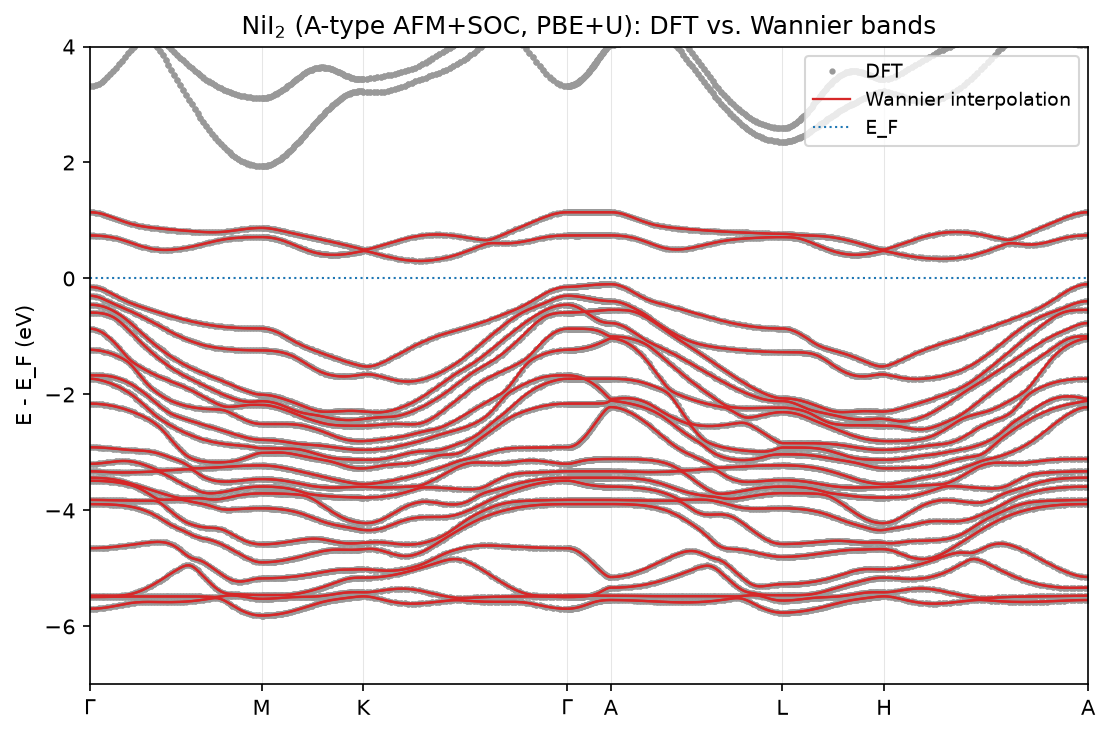

In [6]:
from waw.analysis.kpath import build_kpath
from waw.interfaces.ase.structure import recip_lattice

HEX = {'G': (0, 0, 0), 'M': (0.5, 0, 0), 'K': (1/3, 1/3, 0),
       'A': (0, 0, 0.5), 'L': (0.5, 0, 0.5), 'H': (1/3, 1/3, 0.5)}
seq = ['G', 'M', 'K', 'G', 'A', 'L', 'H', 'A']
segs = [(seq[i], np.array(HEX[seq[i]]), seq[i+1], np.array(HEX[seq[i+1]]))
        for i in range(len(seq) - 1)]
kp = build_kpath(segs, recip_lattice(atoms), n_points=60)

qe.write_pw_input(
    WORK / 'nii2.bands.in', atoms,
    control={'calculation': 'bands', 'prefix': 'nii2', 'outdir': './out',
             'pseudo_dir': str(PSEUDO_DIR), 'verbosity': 'high'},
    system={'ecutwfc': 70, 'nbnd': 100, **SOC},
    electrons={'conv_thr': 1.0e-8},
    pseudopotentials={'Ni': 'Ni-rel.upf', 'I': 'I-rel.upf'},
    kpoints=('crystal', kp.kpts),
    hubbard=HUBBARD, hubbard_projector='ortho-atomic',
)
qe.run_pw(WORK / 'nii2.bands.in', WORK / 'nii2.bands.out', ncores=NCORES)
dft_bands = read_bands_eigenvalues(WORK / 'nii2.bands.out', nbnd=100)
wann_bands = interpolate_bands(result.hr, kp.kpts) * HARTREE_TO_EV

xlabels = [l.replace('G', r'$\Gamma$') for l in kp.tick_labels]
fig, ax = plt.subplots(figsize=(7.5, 5), dpi=150)
for ib in range(dft_bands.shape[1]):
    ax.plot(kp.dists, dft_bands[:, ib] - E_FERMI, 'o', ms=2.0, color='0.6',
            label='DFT' if ib == 0 else None)
for ib in range(wann_bands.shape[1]):
    ax.plot(kp.dists, wann_bands[:, ib] - E_FERMI, '-', lw=1.1, color='C3',
            label='Wannier interpolation' if ib == 0 else None)
ax.axhline(0.0, color='C0', ls=':', lw=1, label='E_F')
ax.set_xticks(kp.tick_dists); ax.set_xticklabels(xlabels)
for x in kp.tick_dists:
    ax.axvline(x, color='0.9', lw=0.5, zorder=0)
ax.set_xlim(kp.dists[0], kp.dists[-1]); ax.set_ylim(-7, 4)
ax.set_ylabel('E - E_F (eV)')
ax.set_title('NiI$_2$ (A-type AFM+SOC, PBE+U): DFT vs. Wannier bands')
ax.legend(fontsize=9, loc='upper right'); plt.tight_layout(); plt.show()

### 4. Surface spectral function on the (001) van-der-Waals cleave
$A(\mathbf k_\parallel, E)=-\tfrac1\pi\,\mathrm{Im\,Tr}\,G_s$ of the semi-infinite crystal cleaved ⟂ $c$ (Lopez-Sancho/Rubio decimation, `analysis.surface`), along $\bar\Gamma\!\to\!\bar M\!\to\!\bar K\!\to\!\bar\Gamma$ of the hexagonal surface BZ. This is the simulated ARPES dispersion; its constant-energy cuts are the doped Fermi surfaces of Section 5.

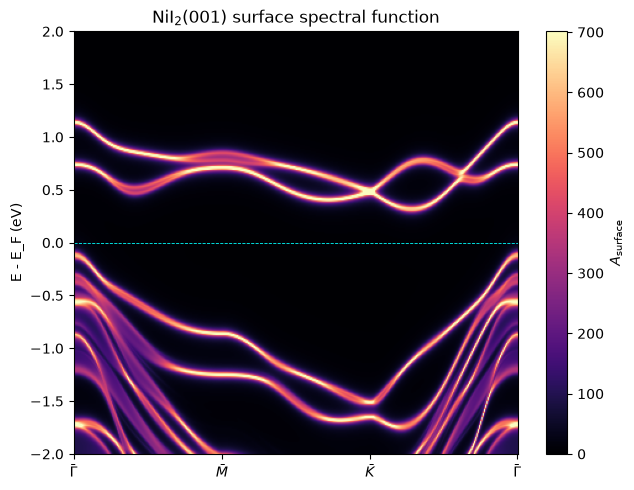

In [7]:
NK = 120
def _seg(a, b, n, end=False): return np.linspace(a, b, n, endpoint=end)
G, M, K = np.array([0., 0.]), np.array([0.5, 0.]), np.array([1/3, 1/3])
kpath = np.concatenate([_seg(G, M, NK), _seg(M, K, NK), _seg(K, G, NK, end=True)])
seg_bounds = [0, NK, 2 * NK, 3 * NK - 1]

energies_eV = E_FERMI + np.linspace(-2.0, 2.0, 320)
sf = surface_spectral_function(result.hr, real_lattice_, MILLER, kpath,
                               energies_eV * EV_TO_HARTREE, eta=0.02 * EV_TO_HARTREE)

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(sf.A_surface.T, origin='lower', aspect='auto', cmap='magma',
               extent=[0, len(kpath), energies_eV[0] - E_FERMI, energies_eV[-1] - E_FERMI],
               vmin=0, vmax=np.percentile(sf.A_surface, 99))
ax.axhline(0.0, color='cyan', lw=0.6, ls='--')
ax.set_xticks(seg_bounds)
ax.set_xticklabels([r'$\bar\Gamma$', r'$\bar M$', r'$\bar K$', r'$\bar\Gamma$'])
ax.set_ylabel('E - E_F (eV)')
fig.colorbar(im, ax=ax, label=r'$A_\mathrm{surface}$')
ax.set_title('NiI$_2$(001) surface spectral function')
plt.tight_layout(); plt.show()

### 5. Doping evolution of the 2D Fermi surface
The constant-energy cut $A(k_x,k_y,\,E=\mu)$ of the (001) surface spectral function over the 2D surface Brillouin zone — i.e. the **Fermi surface** — as the chemical potential $\mu$ is rigid-band shifted (electron/hole doping, e.g. gating or intercalation). Bright contours are the Fermi-surface sheets; as $\mu$ sweeps through the Ni-$3d$/I-$5p$ manifold the pockets grow, shrink, and change topology (Lifshitz transitions). $k_x,k_y$ span the hexagonal surface BZ ($\bar\Gamma$ at the centre).

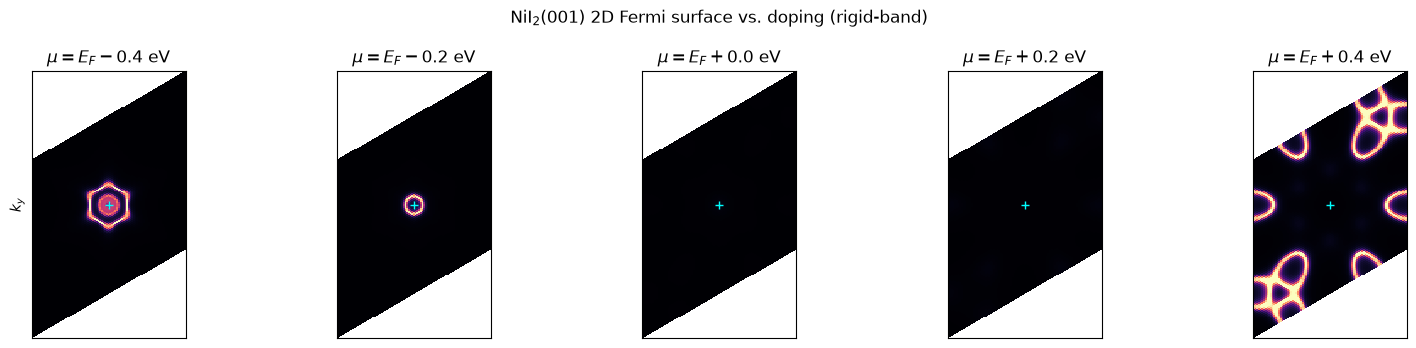

In [8]:
# 2D surface reciprocal vectors (conjugate to the surface cell c1,c2 = v1,v2)
a2d = real_lattice_[:2, :2]                    # in-plane real vectors (Bohr)
g2d = 2 * np.pi * np.linalg.inv(a2d).T         # rows g1, g2 (1/Bohr)

N = 91
f = np.linspace(-0.5, 0.5, N)
F1, F2 = np.meshgrid(f, f, indexing='ij')
frac = np.stack([F1.ravel(), F2.ravel()], axis=1)     # surface-BZ fractional (nk,2)
kcart = frac @ g2d
KX = kcart[:, 0].reshape(N, N); KY = kcart[:, 1].reshape(N, N)

dmus = [-0.4, -0.2, 0.0, 0.2, 0.4]
mus_eV = E_FERMI + np.array(dmus)
fs = surface_spectral_function(result.hr, real_lattice_, MILLER, frac,
                               mus_eV * EV_TO_HARTREE, eta=0.015 * EV_TO_HARTREE)
vmax = np.percentile(fs.A_surface, 99)

fig, axes = plt.subplots(1, len(dmus), figsize=(3.2 * len(dmus), 3.5))
for i, (ax, dmu) in enumerate(zip(axes, dmus)):
    A2d = fs.A_surface[:, i].reshape(N, N)
    ax.pcolormesh(KX, KY, A2d, cmap='magma', vmin=0, vmax=vmax, shading='auto')
    ax.plot(0, 0, '+', color='cyan', ms=6, mew=1.0)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(rf'$\mu = E_F {dmu:+.1f}$ eV')
axes[0].set_ylabel(r'$k_y$')
fig.suptitle('NiI$_2$(001) 2D Fermi surface vs. doping (rigid-band)')
plt.tight_layout(); plt.show()

### 6. Photoemission matrix elements: a direct link to ARPES
The bare $A(\mathbf k_\parallel,E)$ above is the single-particle spectral function; a real ARPES experiment measures it *weighted by the photoemission matrix element*, $I\propto M^\dagger A\,M$ with $M_a(\mathbf k_f)$ the dipole amplitude from Wannier orbital $a$ to the photoelectron final state (`analysis.arpes`, plane-wave-final-state / sudden approximation). $M$ encodes the **structure-factor phase** $e^{i\mathbf k_f\cdot\mathbf r_a}$ (BZ-dependent intensity), the **dipole selection rules** $\ell\!\to\!\ell\pm1$, and the **light polarization** — so bands brighten or vanish depending on their Ni-$3d$/I-$5p$ orbital symmetry and the experimental geometry. Below: the bare $A$ vs. the matrix-element intensity for out-of-plane ($\varepsilon\parallel c$) and in-plane ($\varepsilon\parallel a$) polarization at $h\nu=100$ eV — the same physics an experimentalist uses polarization to disentangle orbital character.

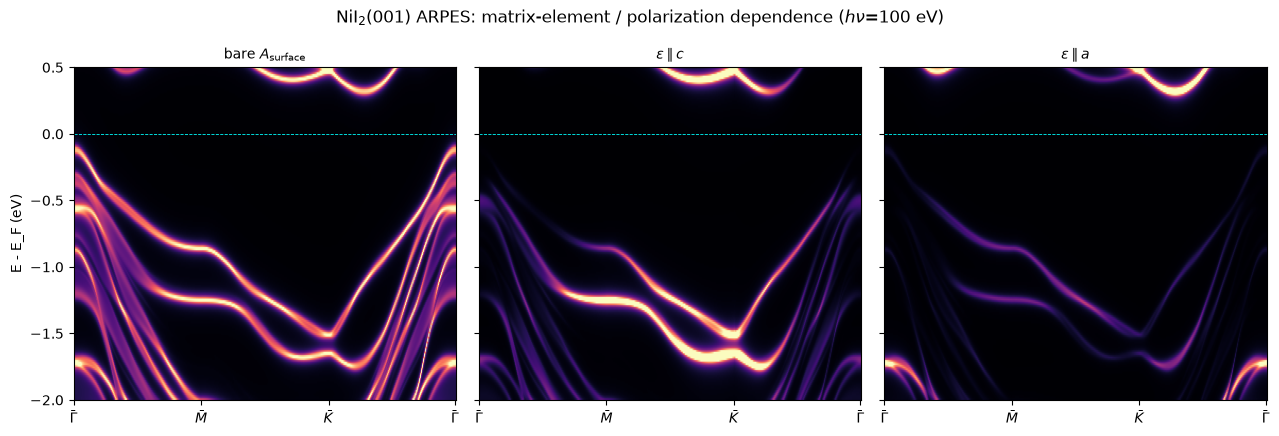

In [9]:
from waw.analysis.arpes import photoemission_matrix_element, wannier_lm_from_projections

wf_lm = wannier_lm_from_projections(projections, spinor=True)   # (l,mr) per WF, hr order
wf_ctr = result.centres_bohr                                    # Bohr, Cartesian
kpar_cart = kpath @ g2d                                         # surface-path k|| -> Cartesian
HV = 100.0                                                      # photon energy (eV); tunable

POLS = [(r'$\varepsilon \parallel c$', [0, 0, 1]),
        (r'$\varepsilon \parallel a$', [1, 0, 0])]
arpes = []
for _, eps in POLS:
    M = photoemission_matrix_element(kpar_cart, wf_ctr, wf_lm, eps, HV)
    sfp = surface_spectral_function(result.hr, real_lattice_, MILLER, kpath,
                                    energies_eV * EV_TO_HARTREE,
                                    eta=0.02 * EV_TO_HARTREE, matrix_element=M)
    arpes.append(sfp.A_arpes)

panels = [('bare $A_\\mathrm{surface}$', sf.A_surface)] + \
         [(POLS[i][0], arpes[i]) for i in range(len(POLS))]
fig, axes = plt.subplots(1, len(panels), figsize=(4.3 * len(panels), 4.4), sharey=True)
for ax, (title, img) in zip(axes, panels):
    ax.imshow(img.T, origin='lower', aspect='auto', cmap='magma',
              extent=[0, len(kpath), energies_eV[0] - E_FERMI, energies_eV[-1] - E_FERMI],
              vmin=0, vmax=np.percentile(img, 99))
    ax.axhline(0.0, color='cyan', lw=0.6, ls='--')
    ax.set_xticks(seg_bounds)
    ax.set_xticklabels([r'$\bar\Gamma$', r'$\bar M$', r'$\bar K$', r'$\bar\Gamma$'])
    ax.set_title(title, fontsize=10); ax.set_ylim(-2.0, 0.5)
axes[0].set_ylabel('E - E_F (eV)')
fig.suptitle(rf'NiI$_2$(001) ARPES: matrix-element / polarization dependence ($h\nu$={HV:.0f} eV)')
plt.tight_layout(); plt.show()

**Takeaway.** From the experimental NiI₂ structure (COD 9009133), a PBE+D3+U (Liechtenstein $U=3.24$, $J_H=0.68\,$eV on Ni-$3d$; matching PRB **109**, 014403) noncollinear+SOC calculation in the minimal 2-formula-unit A-type-AFM cell yields a 44-orbital Ni-$3d$/I-$5p$ Wannier model that reproduces the DFT bands across the frozen window, and `analysis.surface` turns it directly into a **simulated ARPES map on the ⟂$c$ cleave** (bands along the hexagonal path of PRB **109**, 014403), the **doped 2D Fermi surface** from its constant-energy cuts, and — via `analysis.arpes` — the **photoemission-matrix-element-weighted** intensity with its polarization/orbital selectivity, the direct bridge to experiment. New capabilities exercised: per-sublattice magnetic species (`qe.magnetization_keys` + ASE tags → `Ni1`/`Ni2`), the `HUBBARD`-card DFT+U path, and Wannier ARPES matrix elements (`photoemission_matrix_element`). *Caveats:* the collinear A-type order is a proxy for NiI₂'s true incommensurate helimagnet (a spin-spiral / larger-cell treatment is the natural next step), and the ARPES matrix element uses a plane-wave final state (relative, not absolute, intensities).